In [3]:
import tapas
from tapas.attacks.set_classifiers import RandomTargetedQueryFeature
from tapas.generators.generator import Raw
from utils.my_attack import MyAttack
from utils.benchmark_pipeline import BenchmarkPipeline

from tapas.generators.generator import ReprosynGenerator
from reprosyn.methods import DS_PRIVBAYES

estimating categorical probs
estimating approx kdes(histogram)
Generator TEST: Raw
Generate datasets
Path: data/shadow_datasets_Raw_4.pkl
COMPLEXITY:  2
COMPLEXITY:  4
COMPLEXITY:  10
COMPLEXITY:  50


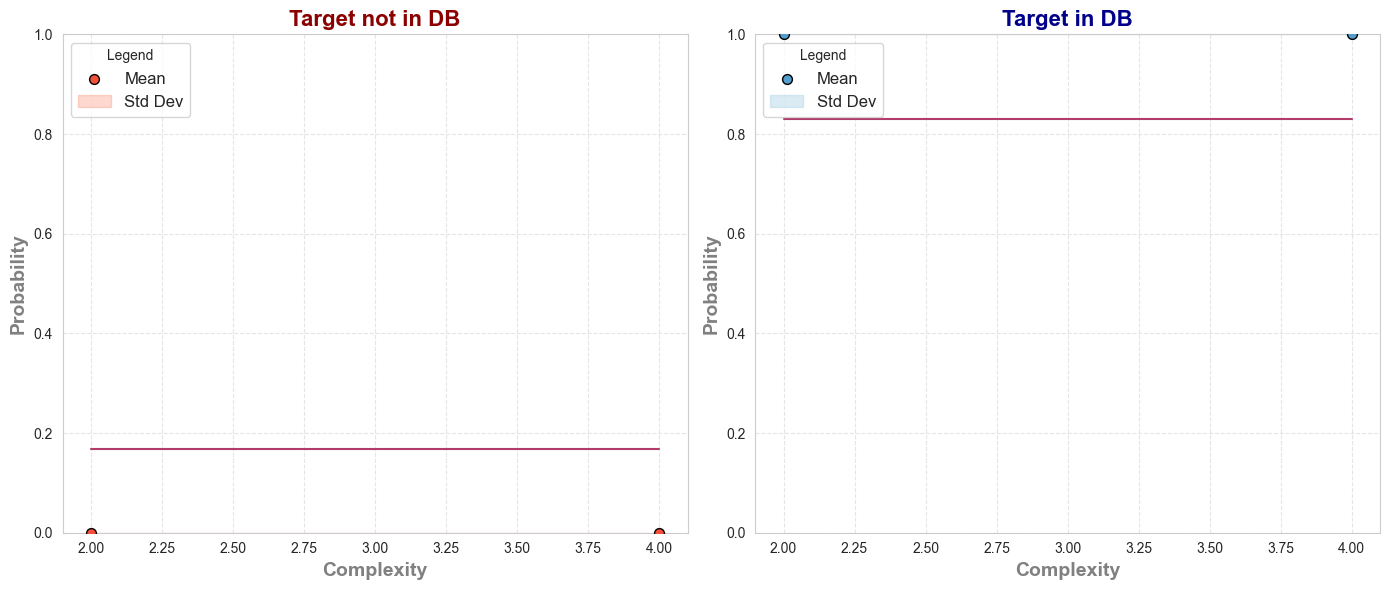

Generator TEST: PrivBayes
Generate datasets
Path: data/shadow_datasets_PrivBayes
COMPLEXITY:  2
COMPLEXITY:  4


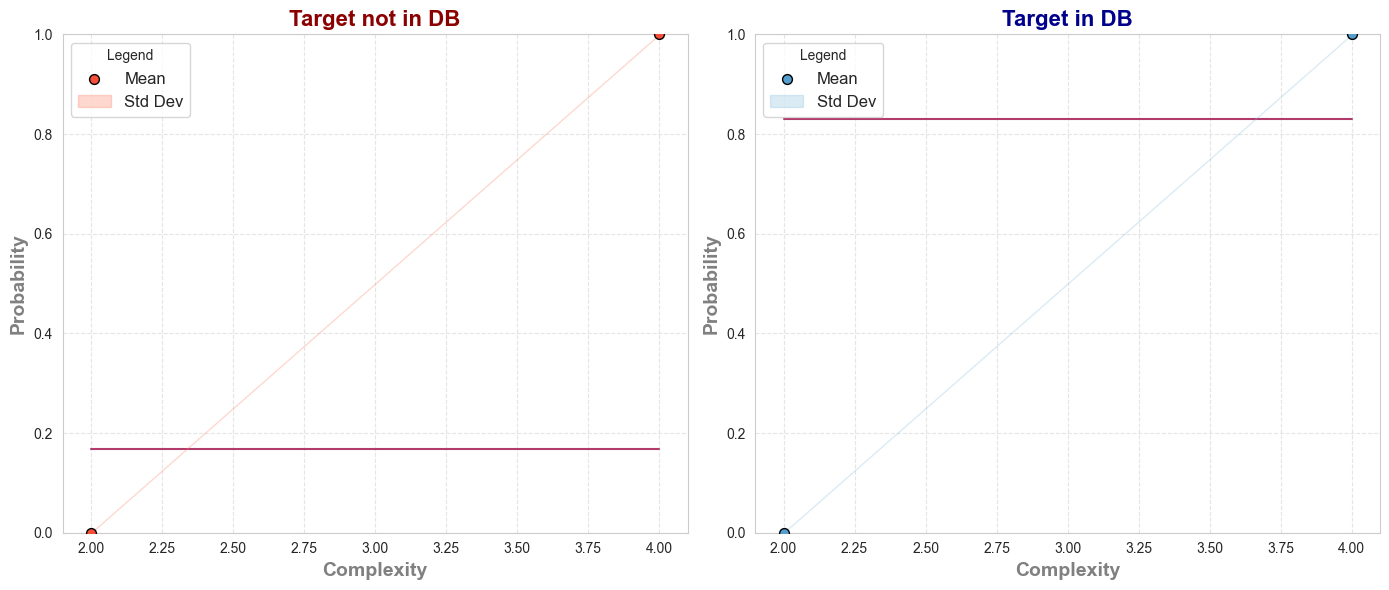

In [4]:
data = tapas.datasets.TabularDataset.read("data/dummy")
target_record = data.get_records([0])
data.drop_records([0], in_place=True)
attack = MyAttack(100, features=RandomTargetedQueryFeature(target_record,3,1))

gen = ReprosynGenerator(DS_PRIVBAYES, label="PrivBayes", epsilon=1.0)

pipeline = BenchmarkPipeline(data, attack, [Raw(),gen], target_record=target_record)

# just add the path to the folder where the generated data will be saved, the name of the file will be generated automatically
pipeline.run([2,4], 1, 2,store_generated_datasets_paths=["data/shadow_datasets_Raw_4.pkl","data/shadow_datasets_PrivBayes"])

# if you want to run the attack without generating data, just set generate=False and add the path to the folder where the generated data will be saved
# pipeline.run_importing_data([2,4], 1, 2, imported_data_path="data/shadow_datasets_Raw_4.pkl")